In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv(r"C:\Users\Dhyaneshwari\Downloads\netflix_titles.csv\netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [14]:
print('Rows, Columns:', df.shape)
print('Duplicate rows:', df.duplicated().sum())
df.isnull().sum()

Rows, Columns: (8807, 12)
Duplicate rows: 0


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [48]:
df.nunique()

show_id         8807
type               2
title           8807
director        4528
cast            7692
country          749
date_added      1714
release_year      74
rating            15
duration         220
listed_in        514
description     8775
year_added        14
duration_num     210
dtype: int64

In [50]:
user_count_country = df.groupby('country')['show_id'].count()
print(user_count_country)

country
, France, Algeria                                       1
, South Korea                                           1
Argentina                                              56
Argentina, Brazil, France, Poland, Germany, Denmark     1
Argentina, Chile                                        2
                                                       ..
Venezuela                                               1
Venezuela, Colombia                                     1
Vietnam                                                 7
West Germany                                            1
Zimbabwe                                                1
Name: show_id, Length: 749, dtype: int64


In [15]:
df[df.duration.isnull()][['title', 'type', 'rating', 'duration']]

,title,type,rating,duration
5541,Louis C.K. 2017,Movie,74 min,NaN
5794,Louis C.K.: Hilarious,Movie,84 min,NaN
5813,Louis C.K.: Live at the Comedy Store,Movie,66 min,NaN


In [16]:
wrong = df['rating'].str.contains('min', na=False)     # True for the 3 bad rows
print('Bad rows found:', wrong.sum())

df.loc[wrong, 'duration'] = df.loc[wrong, 'rating']     # copy value to the correct column
df.loc[wrong, 'rating'] = np.nan                        # empty the wrong column
df[['title', 'rating', 'duration']].loc[wrong]

Bad rows found: 3


,title,rating,duration
5541,Louis C.K. 2017,NaN,74 min
5794,Louis C.K.: Hilarious,NaN,84 min
5813,Louis C.K.: Live at the Comedy Store,NaN,66 min


In [18]:
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')

In [21]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format='%B %d, %Y')
df['year_added'] = df['date_added'].dt.year
df[['date_added', 'year_added']].head()

,date_added,year_added
0,2021-09-25,2021.0
1,2021-09-24,2021.0
2,2021-09-24,2021.0
3,2021-09-24,2021.0
4,2021-09-24,2021.0


In [23]:
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)

movies = df[df['type'] == 'Movie'].copy()      # duration_num = minutes
tv     = df[df['type'] == 'TV Show'].copy()    # duration_num = seasons
movies[['title', 'duration', 'duration_num']].head(3)

,title,duration,duration_num
0,Dick Johnson Is Dead,90 min,90.0
6,My Little Pony: A New Generation,91 min,91.0
7,Sankofa,125 min,125.0


In [24]:
genres = df[['show_id', 'type', 'release_year', 'listed_in']].copy()
genres['genre'] = genres['listed_in'].str.split(', ')
genres = genres.explode('genre').reset_index(drop=True)

countries = df[['show_id', 'release_year', 'country']].copy()
countries['country'] = countries['country'].str.split(', ')
countries = countries.explode('country').reset_index(drop=True)

print('Titles:', len(df), '| Genre rows:', len(genres), '| Country rows:', len(countries))

Titles: 8807 | Genre rows: 19323 | Country rows: 10845


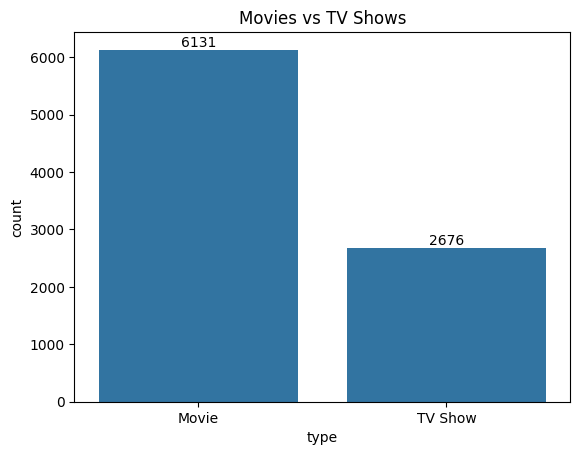

type
Movie      69.6
TV Show    30.4
Name: proportion, dtype: float64


In [29]:
ax = sns.countplot(data=df, x='type')
ax.set_title('Movies vs TV Shows')
for b in ax.patches: ax.annotate(int(b.get_height()), (b.get_x()+b.get_width()/2, b.get_height()), ha='center', va='bottom')
plt.show()
print(df['type'].value_counts(normalize=True).round(3) * 100)

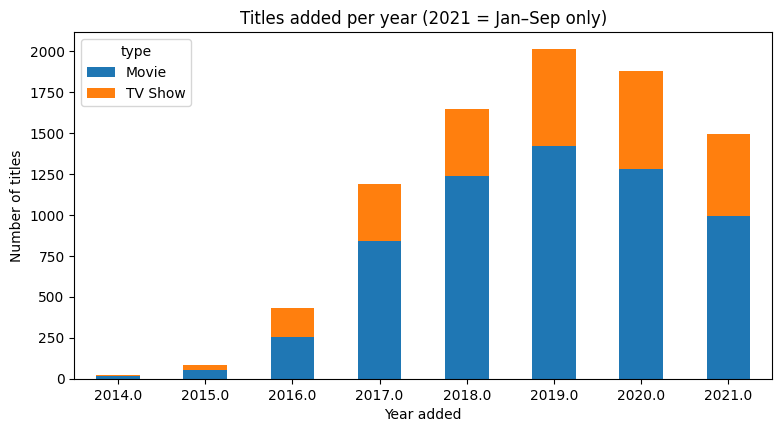

year_added
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
dtype: int64


In [31]:
added = df.groupby(['year_added', 'type']).size().unstack().fillna(0)
added = added.loc[2014:2021]
added.plot(kind='bar', stacked=True, figsize=(9,4.5))
plt.title('Titles added per year (2021 = Jan–Sep only)')
plt.xlabel('Year added'); plt.ylabel('Number of titles'); plt.xticks(rotation=0)
plt.show()
print(added.sum(axis=1).astype(int))

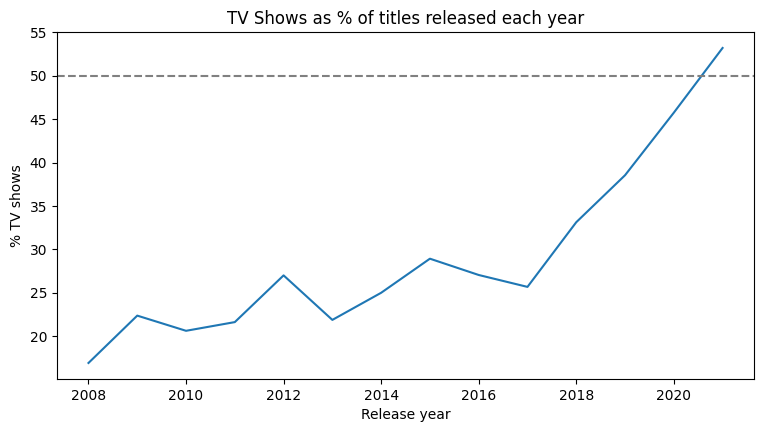

2014: 25 %   2021: 53 %


In [33]:
yr = df[df['release_year'].between(2008, 2021)]
tv_share = yr.groupby('release_year')['type'].apply(lambda s: (s == 'TV Show').mean() * 100)

plt.figure(figsize=(9,4.5))
plt.plot(tv_share.index, tv_share.values)
plt.axhline(50, linestyle='--', color='grey')
plt.title('TV Shows as % of titles released each year')
plt.ylabel('% TV shows'); plt.xlabel('Release year')
plt.show()
print('2014:', round(tv_share[2014]), '%   2021:', round(tv_share[2021]), '%')

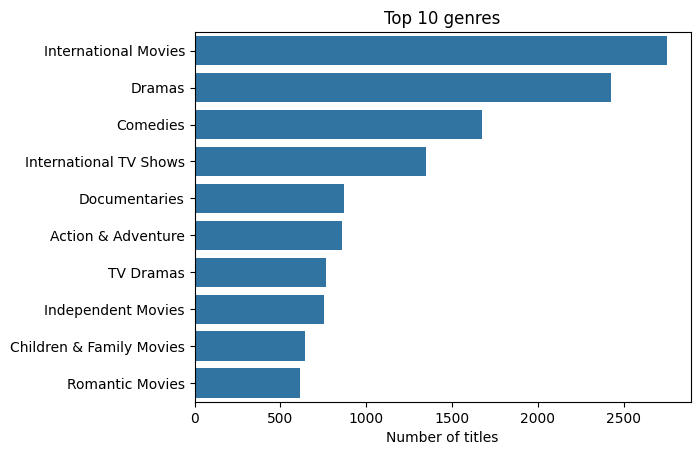

In [35]:
top_genres = genres['genre'].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title('Top 10 genres'); plt.xlabel('Number of titles'); plt.ylabel('')
plt.show()

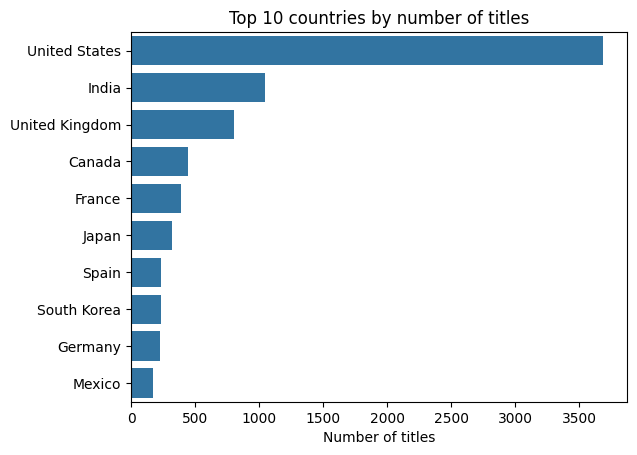

country,United States,India,South Korea,Spain
period,,,,
2000-10,39.2,15.8,0.6,0.9
2011-15,32.0,12.8,2.1,1.5
2016-18,34.8,8.2,2.9,3.1
2019-21,39.5,8.2,3.1,3.2


In [37]:
known = countries[countries['country'] != 'Unknown']
top_c = known['country'].value_counts().head(10)
sns.barplot(x=top_c.values, y=top_c.index)
plt.title('Top 10 countries by number of titles'); plt.xlabel('Number of titles'); plt.ylabel('')
plt.show()

# Share of each country in different time periods
known = known.assign(period=pd.cut(known['release_year'], [1999, 2010, 2015, 2018, 2021],
                                   labels=['2000-10', '2011-15', '2016-18', '2019-21']))
share = pd.crosstab(known['period'], known['country'], normalize='index') * 100
share[['United States', 'India', 'South Korea', 'Spain']].round(1)

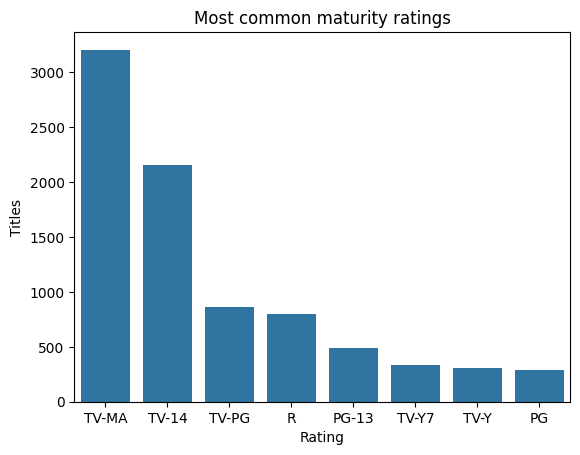

TV-MA + TV-14 = 61% of all titles


In [39]:
rt = df[df['rating'] != 'Unknown']['rating'].value_counts().head(8)
sns.barplot(x=rt.index, y=rt.values)
plt.title('Most common maturity ratings'); plt.xlabel('Rating'); plt.ylabel('Titles')
plt.show()

adult_teen = df['rating'].isin(['TV-MA', 'TV-14']).mean() * 100
print(f'TV-MA + TV-14 = {adult_teen:.0f}% of all titles')

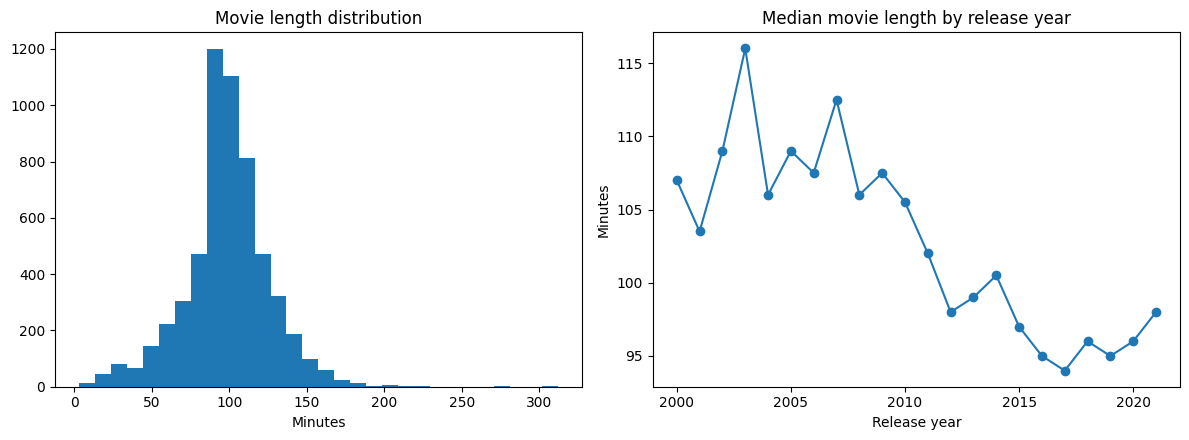

Median before 2010: 108.0 min | 2018 onwards: 96.0 min


In [41]:
m = movies[(movies['release_year'] >= 2000) & movies['duration_num'].notnull()]
med = m.groupby('release_year')['duration_num'].median()

fig, ax = plt.subplots(1, 2, figsize=(12,4.5))
ax[0].hist(m['duration_num'], bins=30)
ax[0].set_title('Movie length distribution'); ax[0].set_xlabel('Minutes')
ax[1].plot(med.index, med.values, marker='o')
ax[1].set_title('Median movie length by release year'); ax[1].set_xlabel('Release year'); ax[1].set_ylabel('Minutes')
plt.tight_layout(); plt.show()

old = movies[movies.release_year < 2010]['duration_num'].median()
new = movies[movies.release_year >= 2018]['duration_num'].median()
print('Median before 2010:', old, 'min | 2018 onwards:', new, 'min')

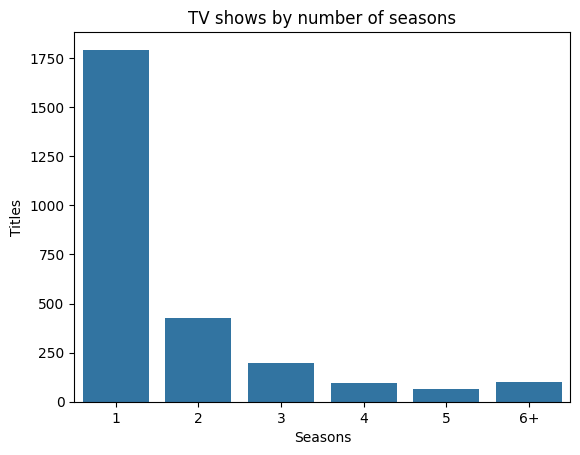

Shows with only 1 season: 67%


In [43]:
seasons = tv['duration_num'].clip(upper=6).value_counts().sort_index()
seasons.index = [f'{int(i)}' if i < 6 else '6+' for i in seasons.index]
sns.barplot(x=seasons.index, y=seasons.values)
plt.title('TV shows by number of seasons'); plt.xlabel('Seasons'); plt.ylabel('Titles')
plt.show()
print(f"Shows with only 1 season: {(tv['duration_num'] == 1).mean() * 100:.0f}%")